In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import torch.optim as optim
import torchvision
import torch.nn.functional as F
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [1]:
import pickle

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

all_deer_images = []

# Loop through all 5 training batches
for i in range(1, 6):
    batch = unpickle(f'./cifar-10-batches-py/data_batch_{i}')
    
    raw_images = batch[b'data']
    labels = np.array(batch[b'labels'])
    
    # Filter indices where label is 4 (deer)
    deer_indices = np.where(labels == 4)[0]
    
    # Extract, reshape, and transpose those specific images
    filtered_images = raw_images[deer_indices].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    all_deer_images.append(filtered_images)

# Concatenate all batches into a single array
deer_dataset = np.concatenate(all_deer_images, axis=0)

print(f"Total deer images extracted: {deer_dataset.shape[0]}")
print("Single sample shape:", deer_dataset[0].shape)
print("Data type:", deer_dataset.dtype)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(deer_dataset[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

C:\Users\mateo\AppData\Local\Temp\ipykernel_11156\2916340599.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


NameError: name 'np' is not defined

In [3]:
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torch.utils.data import TensorDataset, DataLoader

deer_tensor = torch.from_numpy(deer_dataset).permute(0, 3, 1, 2).float() / 255.0
dataset = TensorDataset(deer_tensor)


loader = DataLoader(
    dataset, 
    batch_size=64, 
    shuffle=True, 
    drop_last=True, 
    num_workers=0,
    pin_memory=True       # Speeds up the transfer of data from CPU to GPU
)

Shape of a single sample inside the dataset (CHW): torch.Size([3, 32, 32])


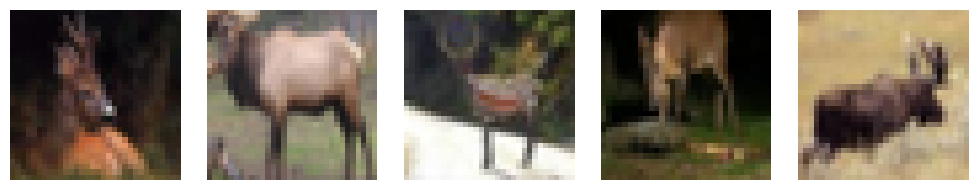

In [14]:
print("Shape of a single sample inside the dataset (CHW):", dataset[0][0].shape)

index = np.random.randint(0, len(dataset), 5)
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for ax, i in zip(axes, index):
    img_tensor = dataset[i][0]
    
    ax.imshow(img_tensor.permute(1, 2, 0).cpu().numpy())
    ax.axis('off')
    
plt.tight_layout()
plt.show()

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VanillaVAE(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2)
        )
        
        self.fc_mu = nn.Linear(1024, latent_dim)
        self.fc_var = nn.Linear(1024, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, 1024)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),  # (16, 32, 32) - New detail layer
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),
            nn.Conv2d(16, 3, kernel_size=3, stride=1, padding=1), # (3, 32, 32) - Clean RGB mapping
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        features = self.encoder(x)
        features = features.view(features.size(0), -1)
        mu = self.fc_mu(features)
        logvar = self.fc_var(features)
        
        z = self.reparameterize(mu, logvar)
        
        z = self.decoder_input(z)
        z = z.view(z.size(0), 256, 2, 2)
        recon = self.decoder(z)
        
        return recon, mu, logvar

In [367]:
def get_beta(epoch, total_epochs=3000, cycles=4, max_betas=[0.01, 0.06, 0.1, 0.2]):
    cycle_length = total_epochs // cycles
    current_cycle = epoch // cycle_length
    step_in_cycle = epoch % cycle_length
    
    ramp_epochs = cycle_length // 2 
    
    # Select the max beta for the current cycle
    cycle_max = max_betas[min(current_cycle, len(max_betas) - 1)]
    
    if step_in_cycle < ramp_epochs:
        # Linear ramp phase: 0 -> cycle_max
        return cycle_max * (step_in_cycle / ramp_epochs)
    else:
        # Stable phase: flat at cycle_max
        return cycle_max
        
def train_vae(num_epochs, loader, model, optimizer):
    model.train()
    model.to(device)
    train_losses = []
    print("Training started")
    start = time.time()
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        beta = 0.02 # get_beta(epoch, num_epochs)
        for deer in loader:
            x = deer.to(device)
            
            recon, mu, logvar = model(x)  # VAE returns three things
            
            recon_loss = F.mse_loss(recon, x, reduction='sum')
            kl_loss = -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
            loss = recon_loss + (beta * kl_loss)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(loader)
        train_losses.append(avg_loss)
        if epoch % 10 == 0:
            print(f"Epoch [{epoch}/{num_epochs}] Loss: {avg_loss:.10f}")
    
    print("Training ended")
    print(f"Elapsed time: {(time.time() - start)/60} minutes")
    return model, train_losses

In [368]:
vae = VanillaVAE(latent_dim=256)
optimizer = optim.AdamW(vae.parameters(), lr=0.001)
vae, losses = train_vae(3000, loader, vae, optimizer)

Training started
Epoch [0/3000] Loss: 4619.9720052083
Epoch [10/3000] Loss: 1820.3544264573
Epoch [20/3000] Loss: 1529.5840892303
Epoch [30/3000] Loss: 1362.7076056065
Epoch [40/3000] Loss: 1279.8947863457
Epoch [50/3000] Loss: 1211.3888706305
Epoch [60/3000] Loss: 1169.2919734075
Epoch [70/3000] Loss: 1141.8090053461
Epoch [80/3000] Loss: 1112.0495801094
Epoch [90/3000] Loss: 1090.0103783241
Epoch [100/3000] Loss: 1058.2547693497
Epoch [110/3000] Loss: 1071.9818662986
Epoch [120/3000] Loss: 1043.9399155837
Epoch [130/3000] Loss: 1022.9598193046
Epoch [140/3000] Loss: 994.7942277957
Epoch [150/3000] Loss: 1000.2190183982
Epoch [160/3000] Loss: 982.8277760041
Epoch [170/3000] Loss: 969.5999395908
Epoch [180/3000] Loss: 955.1280588003
Epoch [190/3000] Loss: 974.6028731909
Epoch [200/3000] Loss: 941.7890515450
Epoch [210/3000] Loss: 957.1352226062
Epoch [220/3000] Loss: 942.6427721855
Epoch [230/3000] Loss: 937.9081147023
Epoch [240/3000] Loss: 928.7775409405
Epoch [250/3000] Loss: 926.41

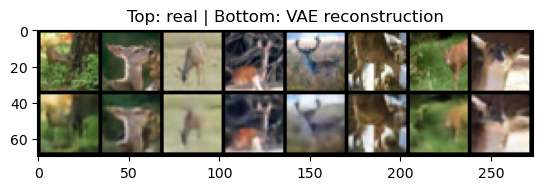

In [369]:
# fixed beta 0.02, lr 0.001, 3k epochs
with torch.no_grad():
    real = next(iter(loader))[:8].to(device)
    recon, _, _ = vae(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

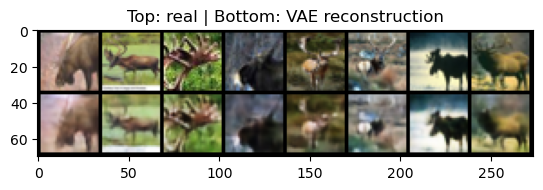

In [239]:
# adaptive kl factor 0.001, 0.003, 0.006, 0.01, lr 0.001, 3k epochs
with torch.no_grad():
    real = next(iter(loader))[:8].to(device)
    recon, _, _ = vae(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

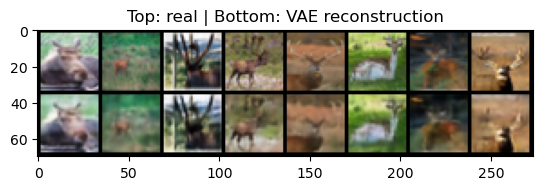

In [233]:
# very small kl factor (0.0001), lr 0.001, 3k epochs
# looks nice but fails at generation tho
with torch.no_grad():
    real = next(iter(loader))[:8].to(device)
    recon, _, _ = vae(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

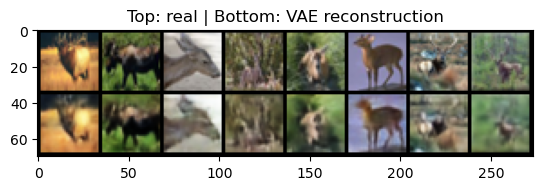

In [222]:
# adaptive kl factor, lr 0.001, 3k epochs
with torch.no_grad():
    real = next(iter(loader))[:8].to(device)
    recon, _, _ = vae(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

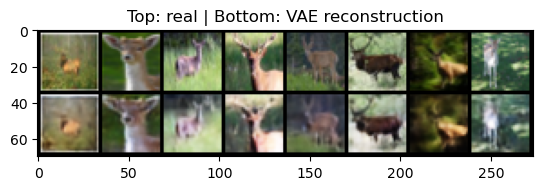

In [191]:
# adaptive kl factor, lr 0.001, 3k epochs
with torch.no_grad():
    real = next(iter(loader))[:8].to(device)
    recon, _, _ = vae(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

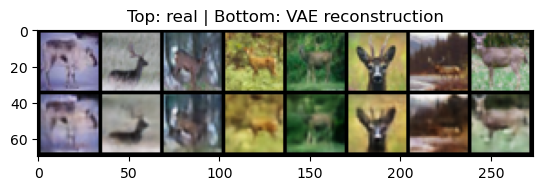

In [56]:
# fixed 0.001 kl factor, lr 0.002, 2k epochs
with torch.no_grad():
    real = next(iter(loader))[:8].to(device)
    recon, _, _ = vae(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

In [326]:
all_latents = []
vae.eval()
with torch.no_grad():
    for deer in loader:
        x = deer.to(device)
        recon, mu, logvar = vae(x)
        z = vae.reparameterize(mu, logvar)
        all_latents.append(z.cpu())

all_latents = torch.cat(all_latents, dim=0) 

In [13]:
def softmax(logits, dim):
    logits = logits - logits.max(dim=dim, keepdim=True).values
    exp = torch.exp(logits)
    return exp / exp.sum(dim=dim, keepdim=True)

def compute_V(y_pos, y_neg, T=0.75, eps=1e-8):
    N = y_neg.shape[0]
    points = torch.cat([y_neg, y_pos],dim=0).to(torch.float32)

    dist = torch.cdist(y_neg, points)
    dist[:, :N] += torch.eye(N, device=dist.device) * 1e6 # So that the point you are standing doesn't influence, really important

    logits = -dist/T # this is log(k(x,y)) for every pair
    A_row = softmax(logits, dim=1)  # Equivalent to Z normalization, Zq and Zp at the same time
    #A_col = softmax(logits, dim=0)  # normalize each column (target) across particles
    #A = torch.sqrt(A_row * A_col)
    A = A_row
    
    A_neg = A[:, :N]
    A_pos = A[:, N:]

    W_pos = A_pos * A_neg.sum(axis=1, keepdims=True) # k(x,y+) scaled by total neg mass
    W_neg = A_neg * A_pos.sum(axis=1, keepdims=True) # k(x,y-) scaled by total pos mass

    drift_pos = W_pos @ y_pos
    drift_neg = W_neg @ y_neg
    V = drift_pos - drift_neg
    
    return V

def loss_function(generated, y_pos, T=0.75): 
    with torch.no_grad():
        V = compute_V(y_pos, generated, T)
        frozen_targets = (generated + V).detach().clone()
    return F.mse_loss(generated, frozen_targets)

In [194]:
class neuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(32, 128), nn.SiLU(),
            nn.Linear(128, 128), nn.SiLU(),
            nn.Linear(128, 256)
        )
    def forward(self, z):
        return self.net(z)

In [201]:
def trainGen(num_epochs, gen, optimizer, gaussian,T, batch_size = 100):
    gen.to(device)
    train_losses = []
    print("Training stared")
    start = time.time()
    for epoch in range(num_epochs+1):
        epoch_loss = 0.0
        gen.train()
        optimizer.zero_grad()

        noise_indices = np.random.choice(10000, batch_size, replace=False)
        real_indices = np.random.choice(len(all_latents), batch_size, replace=False)
        gaussian_batch = gaussian[noise_indices]
        truth_batch = all_latents[real_indices].to(device)

        generated = gen(gaussian_batch)
        loss =  loss_function(generated, truth_batch, T) 
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gen.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss = loss.item()
        train_losses.append(epoch_loss)

        if epoch % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Loss: {epoch_loss:.25f}")

            
    print("Finished")
    print(f"Elapsed time: {(time.time() - start)/60} minutes")

    return gen, train_losses

In [370]:
gen = neuralNet()
# mse = nn.MSELoss()
optimizer = optim.AdamW(gen.parameters(), lr=0.001)
gaussian = torch.from_numpy(np.random.normal(0, 1, [10000, 32])).float().to(device)
gen, losses = trainGen(5000, gen, optimizer, gaussian,T=6,batch_size= 4992)

Training stared
Epoch [0/5000], Loss: 0.0000224093764700228348374
Epoch [100/5000], Loss: 0.0000000080723090434275946
Epoch [200/5000], Loss: 0.0000000485517297477144893
Epoch [300/5000], Loss: 0.0000001819964410287866485
Epoch [400/5000], Loss: 0.0000003710067346673895372
Epoch [500/5000], Loss: 0.0000003026451622645254247
Epoch [600/5000], Loss: 0.0000003815274851604044670
Epoch [700/5000], Loss: 0.0000005428467488854948897
Epoch [800/5000], Loss: 0.0000008299087994600995444
Epoch [900/5000], Loss: 0.0000012709211887340643443
Epoch [1000/5000], Loss: 0.0000006913107881700852886
Epoch [1100/5000], Loss: 0.0000013694201470570988022
Epoch [1200/5000], Loss: 0.0000017459158243582351133
Epoch [1300/5000], Loss: 0.0000024496428068232489750
Epoch [1400/5000], Loss: 0.0000031071281227923464030
Epoch [1500/5000], Loss: 0.0000035835255403071641922
Epoch [1600/5000], Loss: 0.0000032530094813409959897
Epoch [1700/5000], Loss: 0.0000031211225177685264498
Epoch [1800/5000], Loss: 0.000004689852175

In [ ]:
# temp 6 and fixed beta 0.02
evaluate_fid_in_memory(gen, vae, loader)

In [366]:
# temp 0.8 and fixed beta 0.005
evaluate_fid_in_memory(gen, vae, loader)

Processing real images...
Processing generated images...
Computing FID...
FID Score: 358.0928


358.09283447265625

In [363]:
# temp 2 and fixed beta 0.005
evaluate_fid_in_memory(gen, vae, loader)

Processing real images...
Processing generated images...
Computing FID...
FID Score: 148.5156


148.515625

In [361]:
# temp 6 and fixed beta 0.005
evaluate_fid_in_memory(gen, vae, loader)

Processing real images...
Processing generated images...
Computing FID...
FID Score: 154.3447


154.3446807861328

In [348]:
# temp 20 and fixed beta 0.01
evaluate_fid_in_memory(gen, vae, loader)

Processing real images...
Processing generated images...
Computing FID...
FID Score: 148.6879


148.68792724609375

In [346]:
# temp 12 and fixed beta 0.01
evaluate_fid_in_memory(gen, vae, loader)

Processing real images...
Processing generated images...
Computing FID...
FID Score: 137.1662


137.16622924804688

In [344]:
# temp 7 and fixed beta 0.01
evaluate_fid_in_memory(gen, vae, loader)

Processing real images...
Processing generated images...
Computing FID...
FID Score: 135.9473


135.9473114013672

In [339]:
# temp 5 and fixed beta 0.01
evaluate_fid_in_memory(gen, vae, loader)

Processing real images...
Processing generated images...
Computing FID...
FID Score: 136.4019


136.40194702148438

In [332]:
# temp 1.5 and fixed beta 0.01
evaluate_fid_in_memory(gen, vae, loader)

Processing real images...
Processing generated images...
Computing FID...
FID Score: 148.2390


148.239013671875

In [328]:
# temp 2 and fixed beta 0.01
evaluate_fid_in_memory(gen, vae, loader)

Processing real images...
Processing generated images...
Computing FID...
FID Score: 140.8067


140.80667114257812

In [335]:
# temp 2.5 and fixed beta 0.01
evaluate_fid_in_memory(gen, vae, loader)

Processing real images...
Processing generated images...
Computing FID...
FID Score: 142.4060


142.40602111816406

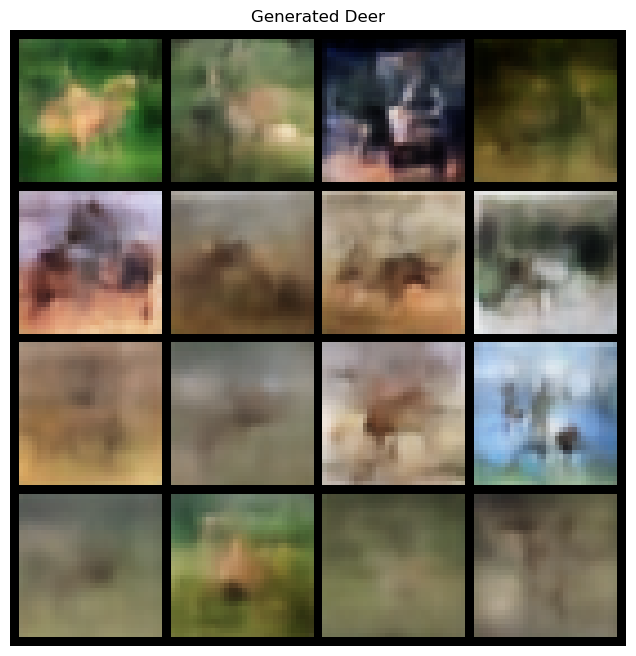

In [342]:
# temp 5 batch  4992 and fixed beta 0.01
gen.eval()
vae.eval()
with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

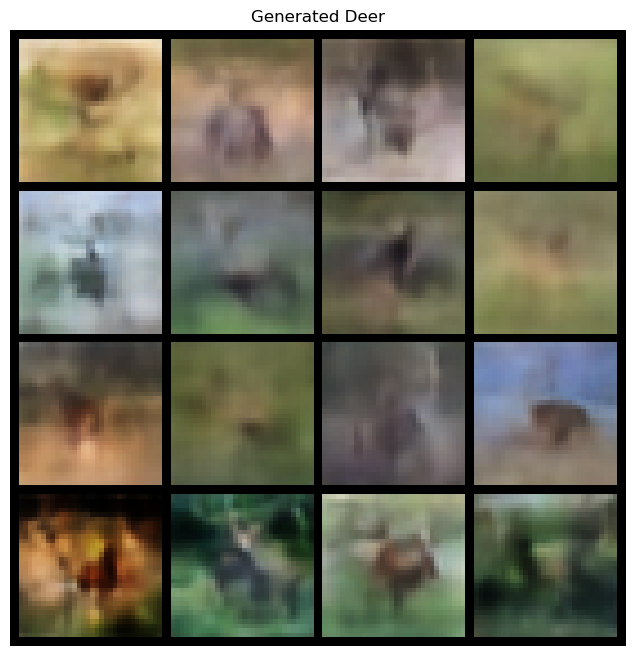

In [337]:
# temp 2.5 batch  4992 and fixed beta 0.01
gen.eval()
vae.eval()
with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

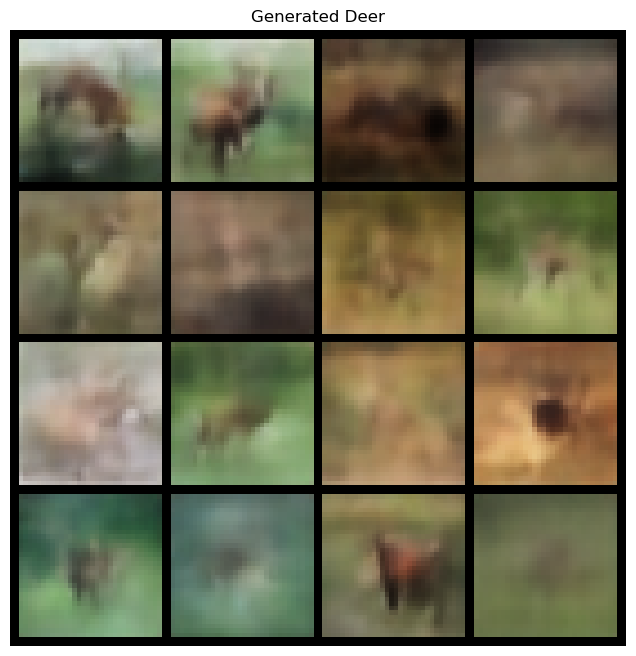

In [329]:
# temp 2 batch  4992 and fixed beta 0.01
gen.eval()
vae.eval()
with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

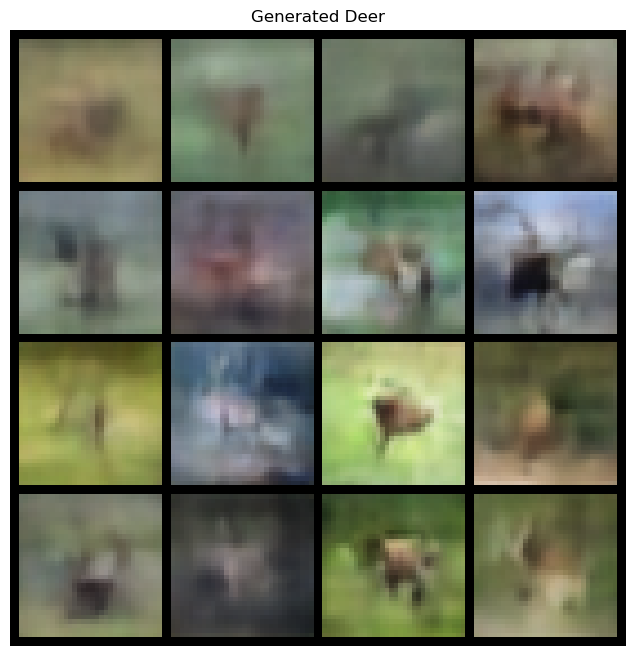

In [333]:
# temp 1.5, fixed beta 0.01
gen.eval()
vae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

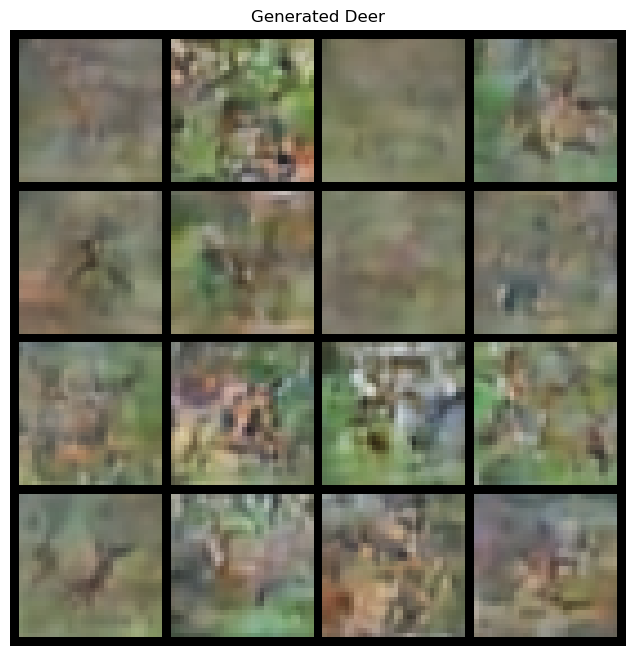

In [236]:
# temp 2 batch  4992 and 0.001 kl sharp vae
# Note: very sharp VAEs may fail to generalize as they overfit the samples and do not learn a good distribution
gen.eval()
vae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

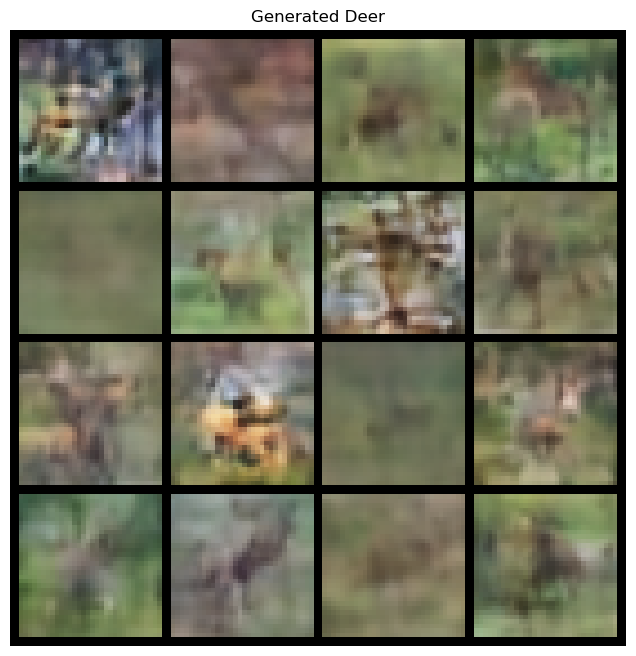

In [230]:
# temp 5 batch 4992
gen.eval()
vae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

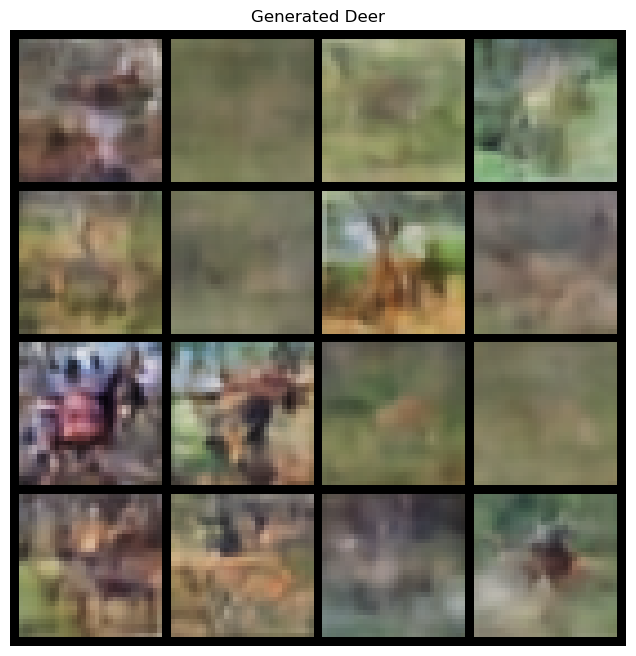

In [224]:
# temp 5 batch 4992
gen.eval()
vae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

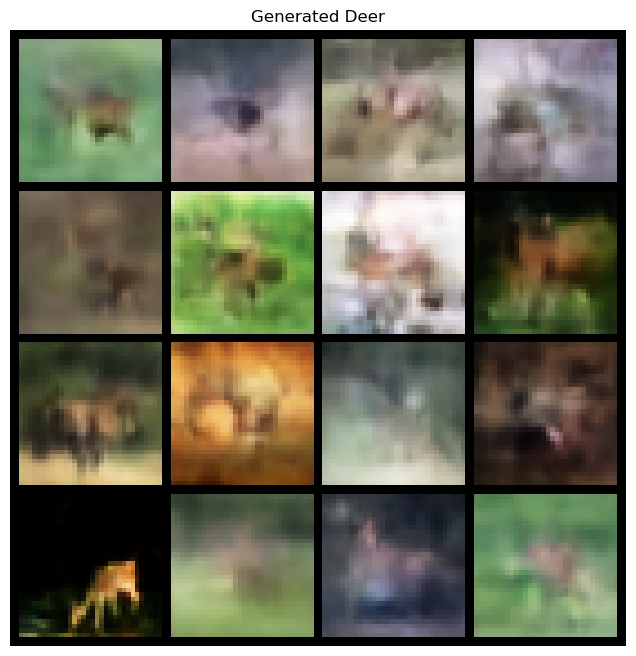

In [215]:
# temp 2 batch 4992
gen.eval()
vae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

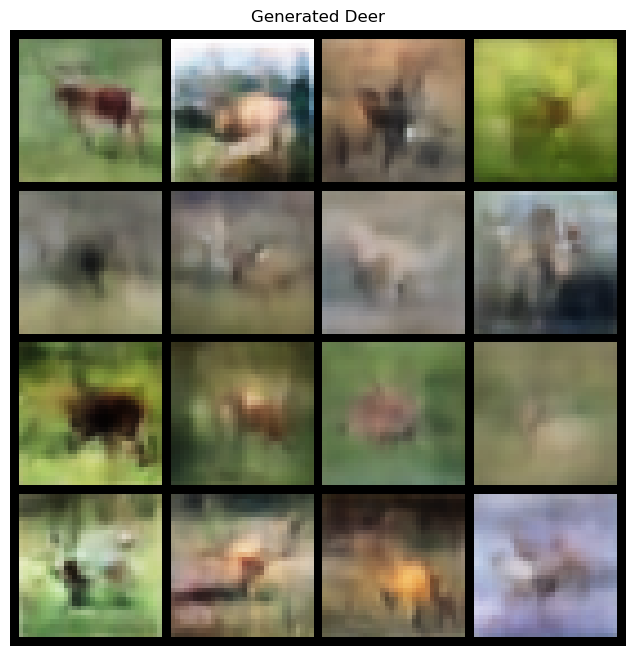

In [216]:
# temp 2 batch 4992
gen.eval()
vae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

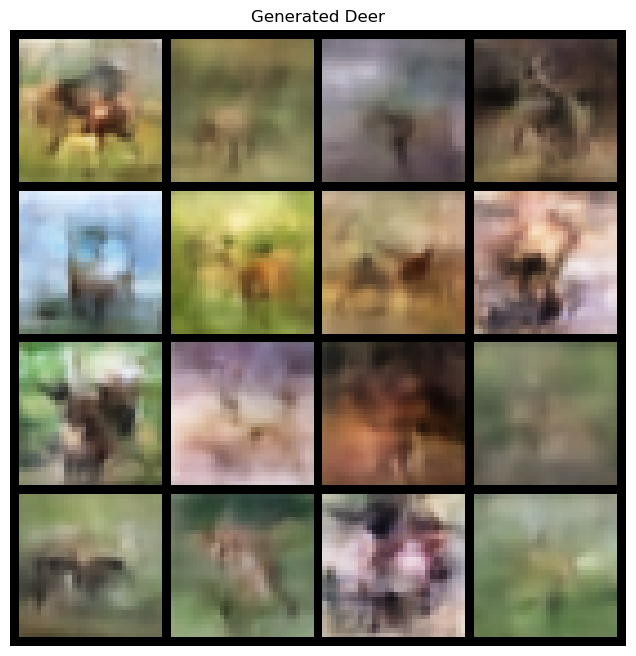

In [208]:
# temp 2.5 batch 4992
gen.eval()
vae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

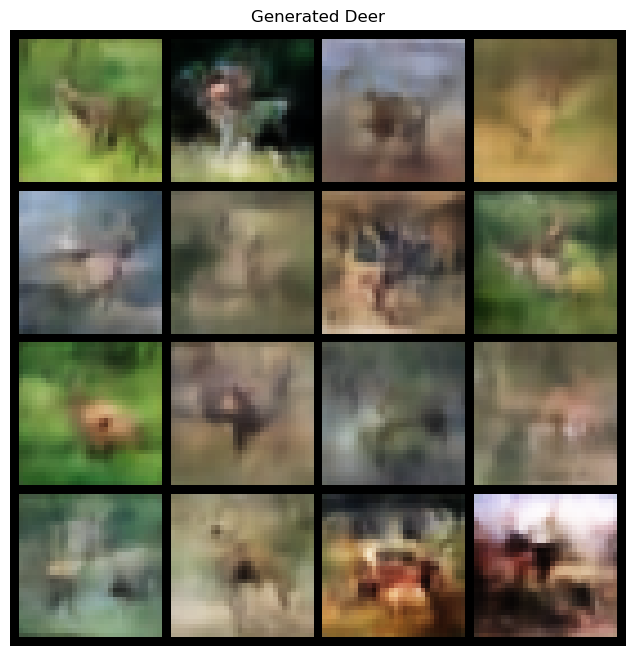

In [209]:
# temp 1.5 batch 4992
gen.eval()
vae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

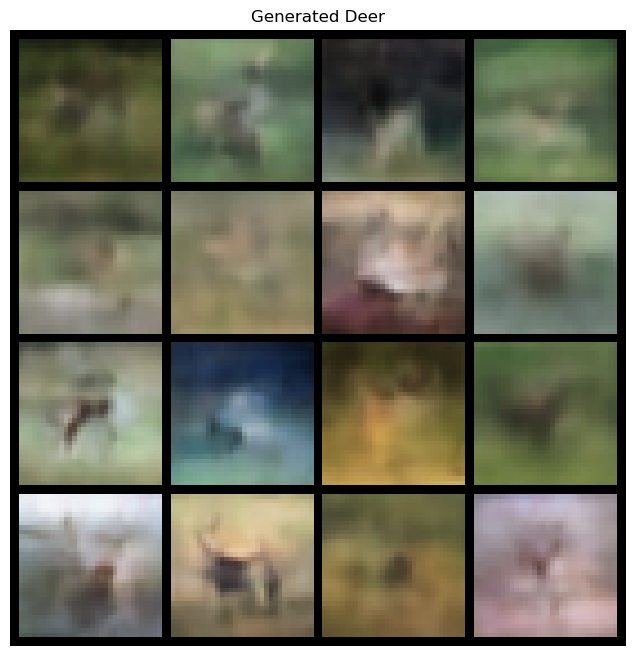

In [186]:
# temp 1.5 batch 4992
gen.eval()
vae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

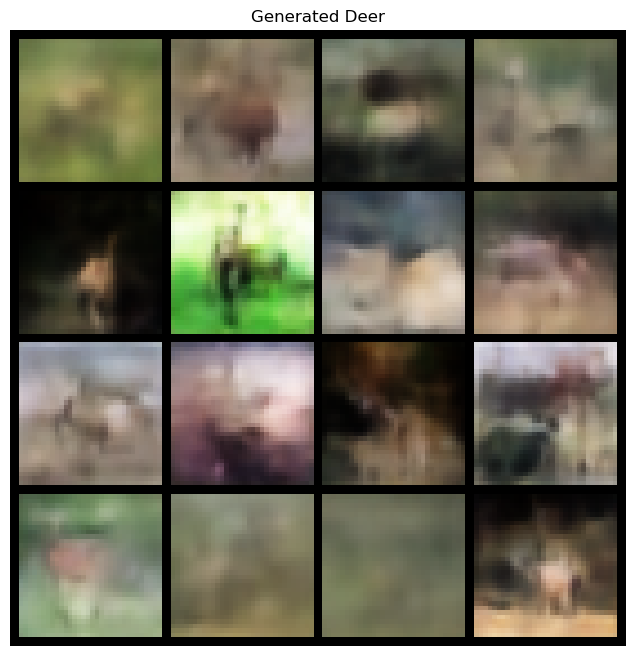

In [176]:
# temp 5 batch 2500
gen.eval()
vae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = gen(noise)
    z = vae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Deer')
plt.show()

# FID

In [ ]:
!pip install torchmetrics[image]

In [317]:
import torch
from torchmetrics.image.fid import FrechetInceptionDistance

def evaluate_fid_in_memory(generator, vae, loader, num_images=4992, batch_size=100):
    # Initialize FID metric (2048 is the standard InceptionV3 feature layer)
    fid = FrechetInceptionDistance(feature=2048).to(device)
    
    generator.eval()
    vae.eval()
    
    print("Processing real images...")
    real_count = 0
    for batch in loader:
        if real_count >= num_images: break
        # Torchmetrics FID expects uint8 tensors in range [0, 255]
        real_uint8 = (batch * 255).to(torch.uint8).to(device)
        fid.update(real_uint8, real=True)
        real_count += batch.size(0)
        
    print("Processing generated images...")
    with torch.no_grad():
        for _ in range(num_images // batch_size):
            noise = torch.randn(batch_size, 32).to(device)
            latents = generator(noise)
            
            # VAE Decoding
            z = vae.decoder_input(latents).view(-1, 256, 2, 2)
            gen_images = vae.decoder(z)
            
            # Clamp to safely map to [0,1], then convert to uint8
            gen_uint8 = (gen_images.clamp(0, 1) * 255).to(torch.uint8).to(device)
            fid.update(gen_uint8, real=False)
            
    print("Computing FID...")
    score = fid.compute().item()
    print(f"FID Score: {score:.4f}")
    
    # Reset to free up memory for the next run
    fid.reset()
    
    return score

In [318]:
evaluate_fid_in_memory(gen, vae, loader)

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to C:\Users\mateo/.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth
100%|███████████████████████████████████████████████████████████████████████████████████████| 91.2M/91.2M [00:18<00:00, 5.27MB/s]


Processing real images...
Processing generated images...
Computing FID...
FID Score: 183.9898


183.9897918701172

# Now with cars

C:\Users\mateo\AppData\Local\Temp\ipykernel_34524\394293071.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


Total car images extracted: 5000
Single sample shape: (32, 32, 3)
Data type: uint8


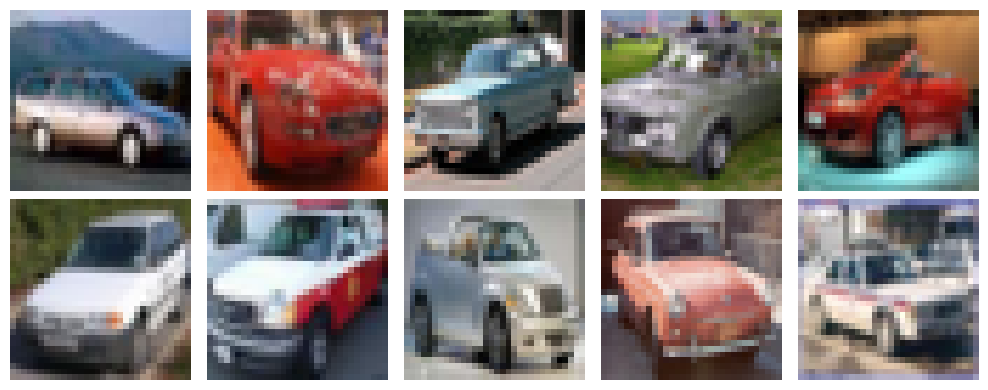

In [256]:
all_car_images = []

# Loop through all 5 training batches
for i in range(1, 6):
    batch = unpickle(f'./cifar-10-batches-py/data_batch_{i}')
    
    raw_images = batch[b'data']
    labels = np.array(batch[b'labels'])
    
    # Filter indices where label is 1 (car)
    car_indices = np.where(labels == 1)[0]
    
    # Extract, reshape, and transpose those specific images
    filtered_images = raw_images[car_indices].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    all_car_images.append(filtered_images)

# Concatenate all batches into a single array
car_dataset = np.concatenate(all_car_images, axis=0)

print(f"Total car images extracted: {car_dataset.shape[0]}")
print("Single sample shape:", car_dataset[0].shape)
print("Data type:", car_dataset.dtype)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(car_dataset[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [259]:
car_tensor = torch.from_numpy(car_dataset).permute(0, 3, 1, 2).float() / 255.0
dataset = TensorDataset(car_tensor)


carLoader = DataLoader(
    car_tensor, 
    batch_size=64, 
    shuffle=True, 
    drop_last=True, 
    num_workers=0,
    pin_memory=True       # Speeds up the transfer of data from CPU to GPU
)

In [260]:
carVae = VanillaVAE(latent_dim=256)
optimizer = optim.AdamW(carVae.parameters(), lr=0.001)
carVae, losses = train_vae(3000, carLoader, carVae, optimizer)

Training started
Epoch [0/3000] Loss: 7739.6427471454
Epoch [10/3000] Loss: 2548.6983799079
Epoch [20/3000] Loss: 1936.3944263947
Epoch [30/3000] Loss: 1618.0044305263
Epoch [40/3000] Loss: 1405.5802127153
Epoch [50/3000] Loss: 1266.0567000952
Epoch [60/3000] Loss: 1156.6252973508
Epoch [70/3000] Loss: 1087.5389513847
Epoch [80/3000] Loss: 1026.0139355782
Epoch [90/3000] Loss: 1007.0393058581
Epoch [100/3000] Loss: 941.1991710174
Epoch [110/3000] Loss: 911.2709178435
Epoch [120/3000] Loss: 890.3266679813
Epoch [130/3000] Loss: 853.4562675280
Epoch [140/3000] Loss: 837.6609011919
Epoch [150/3000] Loss: 813.6275619116
Epoch [160/3000] Loss: 810.8234565930
Epoch [170/3000] Loss: 773.8570048014
Epoch [180/3000] Loss: 768.0291231596
Epoch [190/3000] Loss: 748.6206187713
Epoch [200/3000] Loss: 742.5572337615
Epoch [210/3000] Loss: 713.8075538048
Epoch [220/3000] Loss: 713.9690747383
Epoch [230/3000] Loss: 708.6432667268
Epoch [240/3000] Loss: 709.5816016564
Epoch [250/3000] Loss: 682.8602122

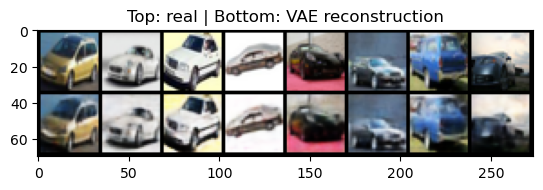

In [269]:
# adaptive kl factor 0.01, 0.03, 0.06, 0.1, lr 0.001, 3k epochs
with torch.no_grad():
    real = next(iter(carLoader))[:8].to(device)
    recon, _, _ = carVae(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

In [267]:
all_latents = []
carVae.eval()
with torch.no_grad():
    for car in carLoader:
        x = car.to(device)
        recon, mu, logvar = carVae(x)
        z = carVae.reparameterize(mu, logvar)
        all_latents.append(z.cpu())

all_latents = torch.cat(all_latents, dim=0) 

In [274]:
carGen = neuralNet()
# mse = nn.MSELoss()
optimizer = optim.AdamW(carGen.parameters(), lr=0.001)
gaussian = torch.from_numpy(np.random.normal(0, 1, [10000, 32])).float().to(device)
carGen, losses = trainGen(5000, carGen, optimizer, gaussian,T=1.7,batch_size= 4992)

Training stared
Epoch [0/5000], Loss: 0.0000000004345586390730460
Epoch [100/5000], Loss: 0.0000000000003357443446525
Epoch [200/5000], Loss: 0.0000000000004982999689956
Epoch [300/5000], Loss: 0.0000000000010157481409798
Epoch [400/5000], Loss: 0.0000000000030472523376152
Epoch [500/5000], Loss: 0.0000000000069089820670110
Epoch [600/5000], Loss: 0.0000000219733244932740490
Epoch [700/5000], Loss: 0.0000001559391904493168113
Epoch [800/5000], Loss: 0.0000004430009710176818771
Epoch [900/5000], Loss: 0.0000008708459517947630957
Epoch [1000/5000], Loss: 0.0000013752934364674729295
Epoch [1100/5000], Loss: 0.0000018505661500967107713
Epoch [1200/5000], Loss: 0.0000025426747924939263612
Epoch [1300/5000], Loss: 0.0000026260602226102491841
Epoch [1400/5000], Loss: 0.0000036328215173853095621
Epoch [1500/5000], Loss: 0.0000041120324567600619048
Epoch [1600/5000], Loss: 0.0000050690582611423451453
Epoch [1700/5000], Loss: 0.0000049656896408123429865
Epoch [1800/5000], Loss: 0.000005452902769

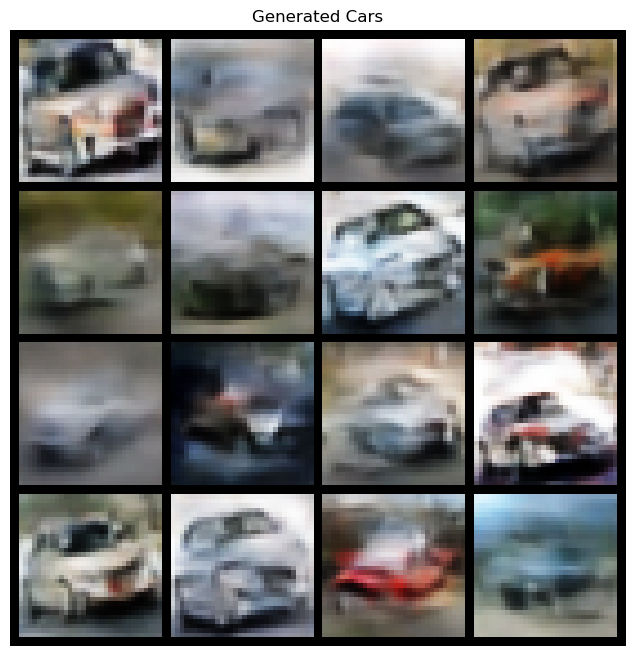

In [278]:
# T = 1.7
carGen.eval()
carVae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = carGen(noise)
    z = carVae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = carVae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Cars')
plt.show()

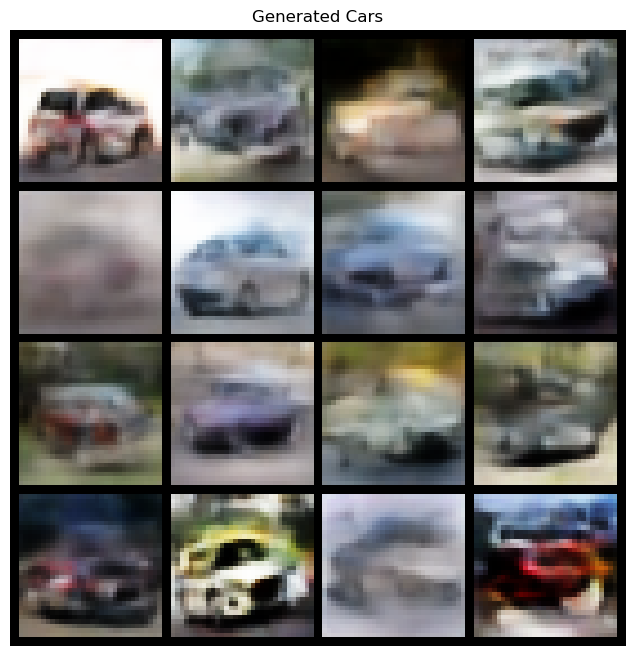

In [270]:
# T = 2
carGen.eval()
carVae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = carGen(noise)
    z = carVae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = carVae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Cars')
plt.show()

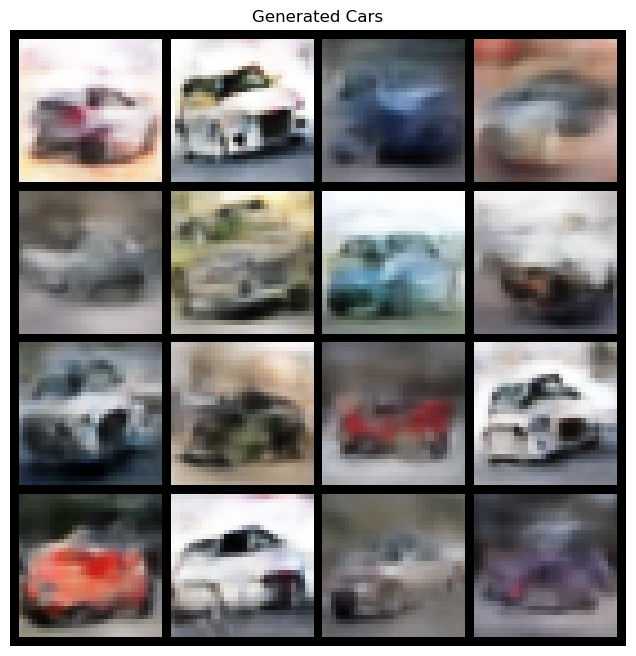

In [271]:
# T = 2
carGen.eval()
carVae.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = carGen(noise)
    z = carVae.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = carVae.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Cars')
plt.show()

In [279]:
!pip install lpips

In [280]:
# LPIPS (Learned Perceptual Image Patch Similarity) is a metric used to measure 
# how similar two images look to the human eye.
import lpips 
import time
import torch
import torch.nn.functional as F

# Load the VGG-based perceptual loss model and move to GPU
perceptual_loss_fn = lpips.LPIPS(net='vgg').to(device)

def train_vae_lpips(num_epochs, loader, model, optimizer):
    model.train()
    model.to(device)
    train_losses = []
    print("Training started with LPIPS")
    start = time.time()
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        beta = get_beta(epoch, num_epochs) # Uses your new 0.01 max schedule
        
        for batch in loader:
            x = batch.to(device)
            recon, mu, logvar = model(x)
            
            # 1. KL Loss
            kl_loss = -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
            
            # 2. Scale from [0, 1] to [-1, 1] for LPIPS
            x_scaled = (x * 2.0) - 1.0
            recon_scaled = (recon * 2.0) - 1.0
            
            # 3. Calculate LPIPS Loss (scaled up to match MSE magnitudes)
            p_loss = perceptual_loss_fn(recon_scaled, x_scaled).sum() * 100.0 
            
            # 4. Standard MSE Loss (helps keep baseline colors accurate)
            mse_loss = F.mse_loss(recon, x, reduction='sum')
            
            # Total Loss
            loss = p_loss + mse_loss + (beta * kl_loss)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(loader)
        train_losses.append(avg_loss)
        
        if epoch % 10 == 0:
            print(f"Epoch [{epoch}/{num_epochs}] Loss: {avg_loss:.4f}")
            
    print(f"Elapsed time: {(time.time() - start)/60:.2f} minutes")
    return model, train_losses

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


C:\Users\mateo\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\mateo\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\mateo/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|█████████████████████████████████████████████████████████████████████████████████████████| 528M/528M [00:45<00:00, 12.1MB/s]


Loading model from: C:\Users\mateo\anaconda3\Lib\site-packages\lpips\weights\v0.1\vgg.pth


In [303]:
vae_lpips = VanillaVAE(latent_dim=256)
optimizer = optim.AdamW(vae_lpips.parameters(), lr=0.001)
vae_lpips, losses = train_vae_lpips(2000, carLoader, vae_lpips, optimizer) #780

Training started with LPIPS
Epoch [0/2000] Loss: 11304.8944
Epoch [10/2000] Loss: 4645.9073
Epoch [20/2000] Loss: 3730.2046
Epoch [30/2000] Loss: 3266.5123
Epoch [40/2000] Loss: 2953.8161
Epoch [50/2000] Loss: 2697.6277
Epoch [60/2000] Loss: 2496.8831
Epoch [70/2000] Loss: 2361.1928
Epoch [80/2000] Loss: 2279.3543
Epoch [90/2000] Loss: 2194.7505
Epoch [100/2000] Loss: 2099.5553
Epoch [110/2000] Loss: 2073.9772
Epoch [120/2000] Loss: 2034.2212
Epoch [130/2000] Loss: 1972.9779
Epoch [140/2000] Loss: 1942.2490
Epoch [150/2000] Loss: 1935.3290
Epoch [160/2000] Loss: 1893.8996
Epoch [170/2000] Loss: 1863.5533
Epoch [180/2000] Loss: 1854.1715
Epoch [190/2000] Loss: 1835.7245
Epoch [200/2000] Loss: 1823.4723
Epoch [210/2000] Loss: 1812.2877
Epoch [220/2000] Loss: 1813.0347
Epoch [230/2000] Loss: 1797.0206
Epoch [240/2000] Loss: 1785.9879
Epoch [250/2000] Loss: 1783.8260
Epoch [260/2000] Loss: 1765.1383
Epoch [270/2000] Loss: 1748.9469
Epoch [280/2000] Loss: 1728.5569
Epoch [290/2000] Loss: 17

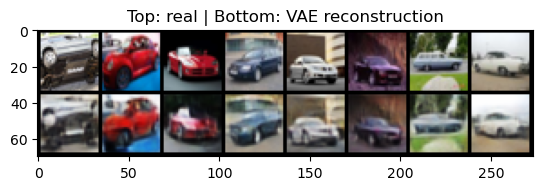

In [304]:
# 0.01 , lr 0.001, 2k epochs
with torch.no_grad():
    real = next(iter(carLoader))[:8].to(device)
    recon, _, _ = vae_lpips(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

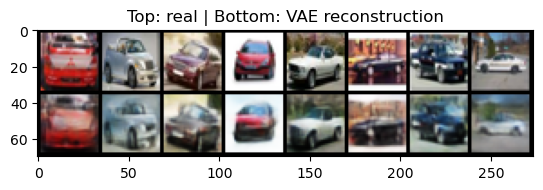

In [293]:
# adaptive kl factor [0.01, 0.06, 0.1, 0.2] , lr 0.001, 2k epochs
with torch.no_grad():
    real = next(iter(carLoader))[:8].to(device)
    recon, _, _ = vae_lpips(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()


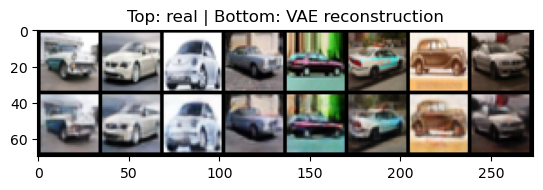

In [282]:
# adaptive kl factor [0.01, 0.06, 0.1, 0.2] , lr 0.001, 2k epochs
with torch.no_grad():
    real = next(iter(carLoader))[:8].to(device)
    recon, _, _ = vae_lpips(real)

grid = torchvision.utils.make_grid(
    torch.cat([real, recon], dim=0), nrow=8
)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.title('Top: real | Bottom: VAE reconstruction')
plt.show()

In [305]:
all_latents = []
vae_lpips.eval()
with torch.no_grad():
    for car in carLoader:
        x = car.to(device)
        recon, mu, logvar = vae_lpips(x)
        z = vae_lpips.reparameterize(mu, logvar)
        all_latents.append(z.cpu())

all_latents = torch.cat(all_latents, dim=0) 

In [311]:
carGen = neuralNet()
# mse = nn.MSELoss()
optimizer = optim.AdamW(carGen.parameters(), lr=0.001)
gaussian = torch.from_numpy(np.random.normal(0, 1, [10000, 32])).float().to(device)
carGen, losses = trainGen(5000, carGen, optimizer, gaussian,T=2,batch_size= 4992)

Training stared
Epoch [0/5000], Loss: 0.0000000017667334262227996
Epoch [100/5000], Loss: 0.0000000000009407237358885
Epoch [200/5000], Loss: 0.0000000000014178668005307
Epoch [300/5000], Loss: 0.0000000000026284419519379
Epoch [400/5000], Loss: 0.0000000000051496606458257
Epoch [500/5000], Loss: 0.0000000000145811435842136
Epoch [600/5000], Loss: 0.0000000000987715673139711
Epoch [700/5000], Loss: 0.0000000007152303194146725
Epoch [800/5000], Loss: 0.0000000011769875074563174
Epoch [900/5000], Loss: 0.0000000036931064872902652
Epoch [1000/5000], Loss: 0.0000000126251453735903851
Epoch [1100/5000], Loss: 0.0000000649216360670834547
Epoch [1200/5000], Loss: 0.0000004874155479228647891
Epoch [1300/5000], Loss: 0.0000014715336646986543201
Epoch [1400/5000], Loss: 0.0000018995799564436310902
Epoch [1500/5000], Loss: 0.0000023914722078188788146
Epoch [1600/5000], Loss: 0.0000019810208868875633925
Epoch [1700/5000], Loss: 0.0000026904417609330266714
Epoch [1800/5000], Loss: 0.000002532543703

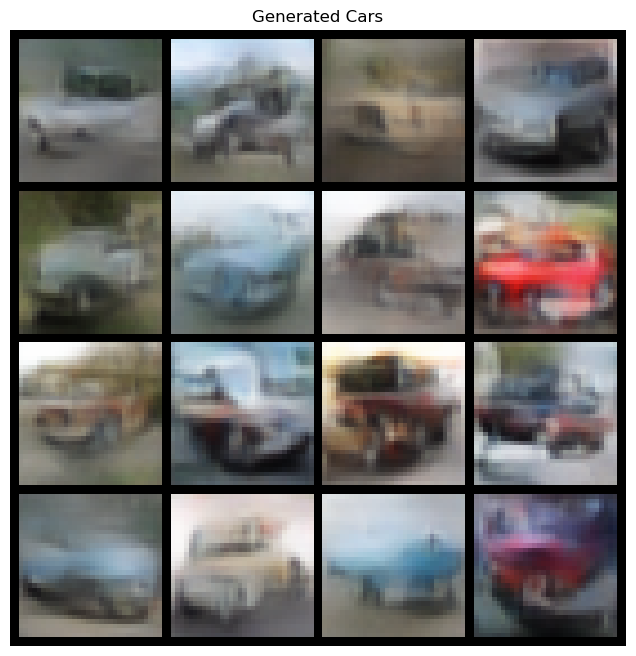

In [313]:
# T=2 0.01 kl 2k iter
carGen.eval()
vae_lpips.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = carGen(noise)
    z = vae_lpips.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae_lpips.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Cars')
plt.show()

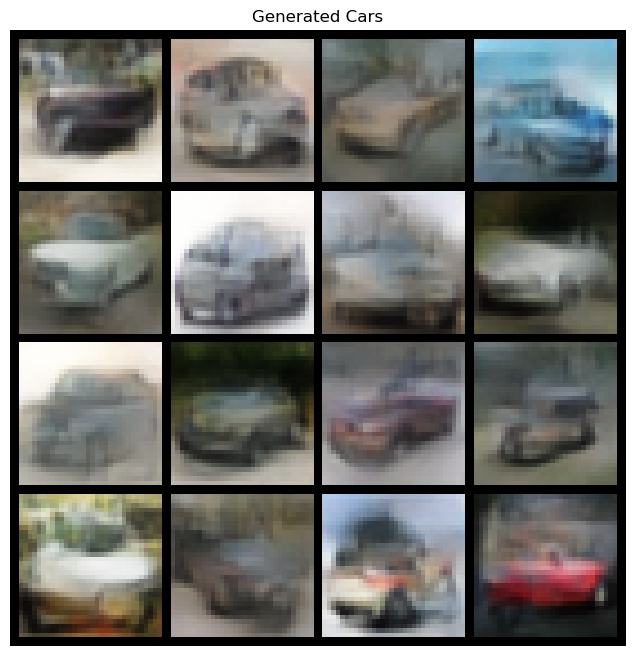

In [301]:
# T 1.7 adaptive beta 3k iter
carGen.eval()
vae_lpips.eval()

with torch.no_grad():
    noise = torch.randn(16, 32).to(device)
    latents = carGen(noise)
    z = vae_lpips.decoder_input(latents)
    z = z.view(z.size(0), 256, 2, 2)
    images = vae_lpips.decoder(z)
    

import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().clip(0, 1))
plt.axis('off')
plt.title('Generated Cars')
plt.show()

In [322]:
evaluate_fid_in_memory(carGen, carVae, carLoader)

Processing real images...
Processing generated images...
Computing FID...
FID Score: 144.5327


144.53271484375







# Now lets try to work in pixel space

In [7]:
from diffusers import UNet2DModel

generator = UNet2DModel(
    sample_size=32,           # Target image resolution
    in_channels=3,            # RGB input
    out_channels=3,           # RGB output
    layers_per_block=2,       # ResNet layers per block
    block_out_channels=(64, 128, 256, 512), # Feature map channels
    down_block_types=(
        "DownBlock2D",        # 32x32 -> 16x16
        "DownBlock2D",        # 16x16 -> 8x8
        "AttnDownBlock2D",    # 8x8 -> 4x4 with spatial attention
        "DownBlock2D",        # 4x4 -> 2x2
    ),
    up_block_types=(
        "UpBlock2D",          # 2x2 -> 4x4
        "AttnUpBlock2D",      # 4x4 -> 8x8 with spatial attention
        "UpBlock2D",          # 8x8 -> 16x16
        "UpBlock2D",          # 16x16 -> 32x32
    ),
).to(device)


Output shape: torch.Size([8, 3, 32, 32])


In [29]:
def softmax(logits, dim):
    logits = logits - logits.max(dim=dim, keepdim=True).values
    exp = torch.exp(logits)
    return exp / exp.sum(dim=dim, keepdim=True)

def compute_V(y_pos, y_neg, T=0.75, eps=1e-8):
    N = y_neg.shape[0]
    points = torch.cat([y_neg, y_pos],dim=0).to(torch.float32)

    dist = torch.cdist(y_neg, points)
    dist = dist / 3072.0
    dist[:, :N] += torch.eye(N, device=dist.device) * 1e6 # So that the point you are standing doesn't influence, really important

    logits = -dist/T # this is log(k(x,y)) for every pair
    A_row = softmax(logits, dim=1)  # Equivalent to Z normalization, Zq and Zp at the same time
    A_col = softmax(logits, dim=0)  # normalize each column (target) across particles
    A = torch.sqrt(A_row * A_col)
    A = A_row
    
    A_neg = A[:, :N]
    A_pos = A[:, N:]

    W_pos = A_pos * A_neg.sum(axis=1, keepdims=True) # k(x,y+) scaled by total neg mass
    W_neg = A_neg * A_pos.sum(axis=1, keepdims=True) # k(x,y-) scaled by total pos mass

    drift_pos = W_pos @ y_pos
    drift_neg = W_neg @ y_neg
    V = drift_pos - drift_neg
    
    return V

def loss_function(generated, y_pos, T=0.75): 
    with torch.no_grad():
        V = compute_V(y_pos, generated, T)
        frozen_targets = (generated + V).detach().clone()
    return F.mse_loss(generated, frozen_targets)

In [30]:
def train(num_epochs, generator, optimizer, gaussian,T, batch_size = 100):
    generator.to(device)
    train_losses = []
    print("Training stared")
    start = time.time()
    loader_iter = iter(loader)
    
    for epoch in range(num_epochs+1):
        generator.train()
        epoch_loss = 0.0
        optimizer.zero_grad()

        try:
            real_batch = next(loader_iter)[0].to(device)
        except StopIteration:
            loader_iter = iter(loader)
            real_batch = next(loader_iter)[0].to(device)

        real_batch = real_batch * 2.0 - 1.0 # Scale images from [0, 1] to [-1, 1]
        batch_size = real_batch.shape[0]

        gaussian_batch = torch.randn(batch_size, 3, 32, 32, device=device)
        # We pass a constant dummy timestep to bypass the Diffusers requirement
        dummy_timesteps = torch.zeros(batch_size, device=device)
        # returns 4D tensor: [batch_size, 3, 32, 32]
        generated = generator(gaussian_batch, dummy_timesteps).sample

        # Flatten tensors to 2D: [batch_size, 3072] 
        generated_flat = generated.view(batch_size, -1)
        real_batch_flat = real_batch.view(batch_size, -1)
        
        # Compute loss using the flattened tensors
        loss = loss_function(generated_flat, real_batch_flat, T)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss = loss.item()
        train_losses.append(epoch_loss)

        if epoch % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Loss: {epoch_loss:.25f}")

            
    print("Finished")
    print(f"Elapsed time: {(time.time() - start)/60} minutes")

    return generator, train_losses

In [ ]:
optimizer = optim.AdamW(generator.parameters(), lr=0.001)
gaussian = torch.from_numpy(np.random.normal(0, 1, [10000, 32])).float().to(device)
generator, losses = train(400, generator, optimizer, gaussian,T=1,batch_size=64)

Training stared
Epoch [0/400], Loss: 0.0002586386399343609809875


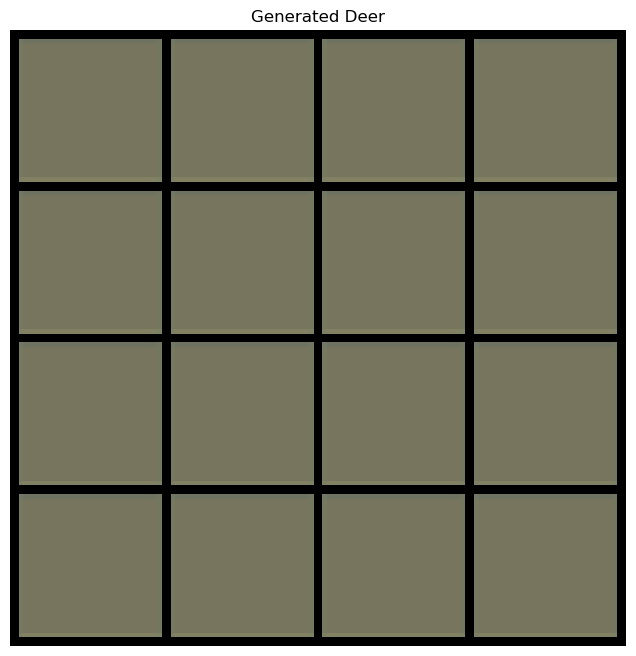

In [36]:
# temp 1 and batch of 64, 400 epochs
generator.eval()

with torch.no_grad():
    # 1. Generate 4D noise in pixel space (16 images, 3 channels, 32x32)
    noise = torch.randn(16, 3, 32, 32).to(device)
    
    # 2. Provide the constant dummy timestep for the U-Net
    dummy_timesteps = torch.zeros(16, device=device)
    
    # 3. Generate images and extract the tensor (.sample)
    images = generator(noise, dummy_timesteps).sample
    
    # 4. Scale back from [-1, 1] to [0, 1] for visualization
    images = (images / 2.0 + 0.5).clamp(0, 1)

import torchvision
import matplotlib.pyplot as plt

grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
# Images are already clamped [0, 1], just convert to numpy for plt
plt.imshow(grid.permute(1, 2, 0).cpu().numpy()) 
plt.axis('off')
plt.title('Generated Deer')
plt.show()

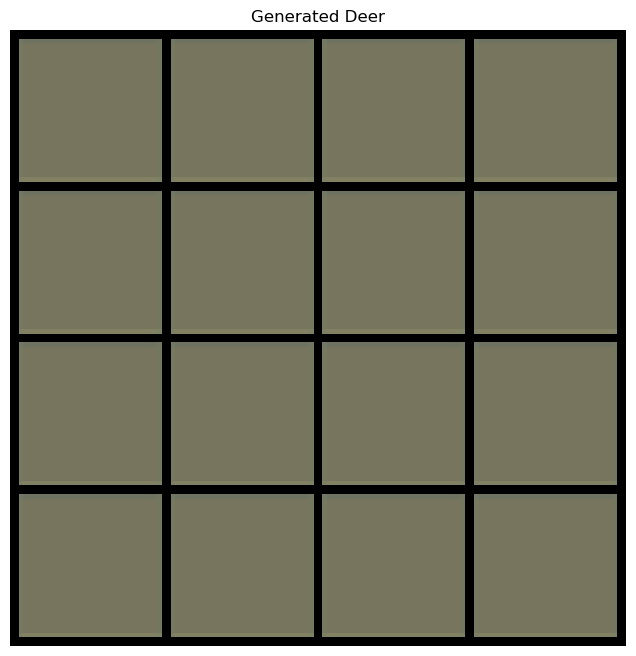

In [36]:
# temp 5 and batch of 200 (only 300 epochs btw)
generator.eval()

with torch.no_grad():
    # 1. Generate 4D noise in pixel space (16 images, 3 channels, 32x32)
    noise = torch.randn(16, 3, 32, 32).to(device)
    
    # 2. Provide the constant dummy timestep for the U-Net
    dummy_timesteps = torch.zeros(16, device=device)
    
    # 3. Generate images and extract the tensor (.sample)
    images = generator(noise, dummy_timesteps).sample
    
    # 4. Scale back from [-1, 1] to [0, 1] for visualization
    images = (images / 2.0 + 0.5).clamp(0, 1)

import torchvision
import matplotlib.pyplot as plt

grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
# Images are already clamped [0, 1], just convert to numpy for plt
plt.imshow(grid.permute(1, 2, 0).cpu().numpy()) 
plt.axis('off')
plt.title('Generated Deer')
plt.show()

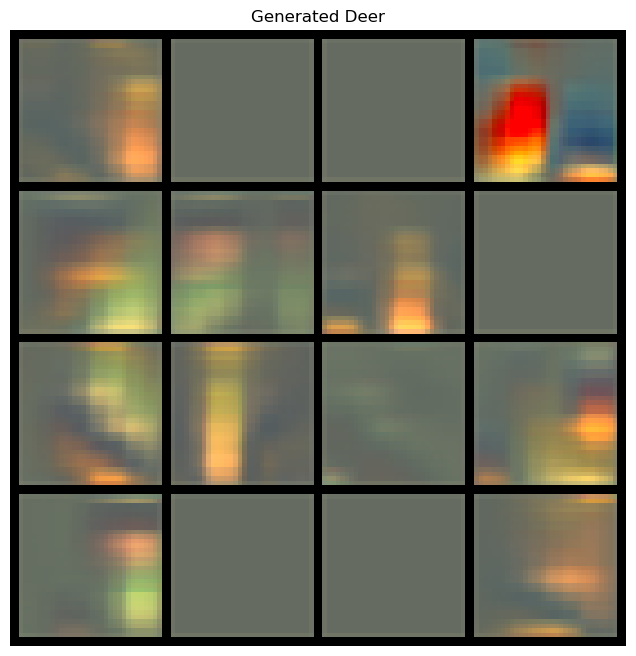

In [32]:
# temp 0.1 and batch of 500
generator.eval()

with torch.no_grad():
    # 1. Generate 4D noise in pixel space (16 images, 3 channels, 32x32)
    noise = torch.randn(16, 3, 32, 32).to(device)
    
    # 2. Provide the constant dummy timestep for the U-Net
    dummy_timesteps = torch.zeros(16, device=device)
    
    # 3. Generate images and extract the tensor (.sample)
    images = generator(noise, dummy_timesteps).sample
    
    # 4. Scale back from [-1, 1] to [0, 1] for visualization
    images = (images / 2.0 + 0.5).clamp(0, 1)

import torchvision
import matplotlib.pyplot as plt

grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
# Images are already clamped [0, 1], just convert to numpy for plt
plt.imshow(grid.permute(1, 2, 0).cpu().numpy()) 
plt.axis('off')
plt.title('Generated Deer')
plt.show()

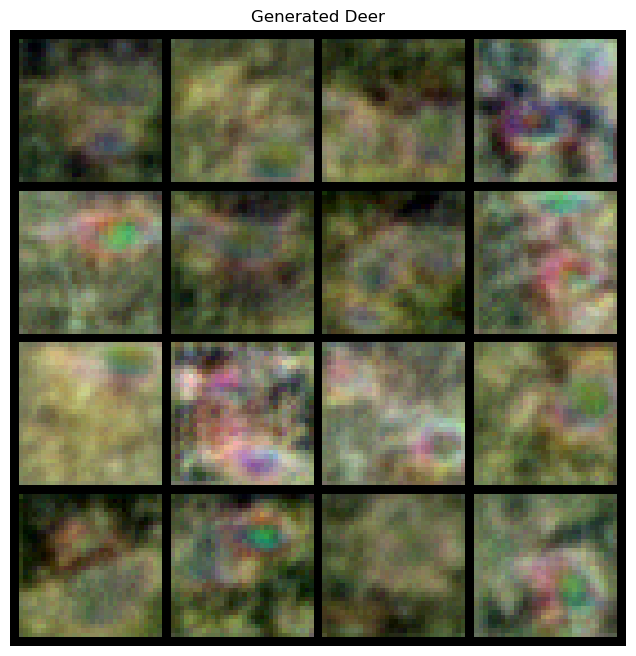

In [23]:
# temp 2 and batch of 64 (without dist = dist / 3072.0 btw)
generator.eval()

with torch.no_grad():
    # 1. Generate 4D noise in pixel space (16 images, 3 channels, 32x32)
    noise = torch.randn(16, 3, 32, 32).to(device)
    
    # 2. Provide the constant dummy timestep for the U-Net
    dummy_timesteps = torch.zeros(16, device=device)
    
    # 3. Generate images and extract the tensor (.sample)
    images = generator(noise, dummy_timesteps).sample
    
    # 4. Scale back from [-1, 1] to [0, 1] for visualization
    images = (images / 2.0 + 0.5).clamp(0, 1)

import torchvision
import matplotlib.pyplot as plt

grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(8, 8))
# Images are already clamped [0, 1], just convert to numpy for plt
plt.imshow(grid.permute(1, 2, 0).cpu().numpy()) 
plt.axis('off')
plt.title('Generated Deer')
plt.show()

In [ ]:
import copy
import math
from collections import deque

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models, transforms


# ============================================================
# 1) DATASET
#    CIFAR-10 deer class only (class_idx=4)
#    If you want cars instead, use class_idx=1
# ============================================================

class FilteredCIFAR10(Dataset):
    def __init__(self, root="./data", train=True, class_idx=4):
        self.base = datasets.CIFAR10(root=root, train=train, download=True)
        self.indices = [i for i, y in enumerate(self.base.targets) if y == class_idx]
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, _ = self.base[self.indices[idx]]
        return self.to_tensor(x)   # [0,1]


# ============================================================
# 2) SMALL IMAGE GENERATOR (UNet-like)
#    This directly maps Gaussian image noise -> RGB image
# ============================================================

class ResBlock(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()

        g1 = min(8, c_in)
        while c_in % g1 != 0 and g1 > 1:
            g1 -= 1

        g2 = min(8, c_out)
        while c_out % g2 != 0 and g2 > 1:
            g2 -= 1

        self.net = nn.Sequential(
            nn.GroupNorm(g1, c_in),
            nn.SiLU(),
            nn.Conv2d(c_in, c_out, 3, padding=1),

            nn.GroupNorm(g2, c_out),
            nn.SiLU(),
            nn.Conv2d(c_out, c_out, 3, padding=1),
        )
        self.skip = nn.Conv2d(c_in, c_out, 1) if c_in != c_out else nn.Identity()

    def forward(self, x):
        return self.net(x) + self.skip(x)


class Down(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.block = nn.Sequential(
            ResBlock(c_in, c_out),
            nn.AvgPool2d(2)
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, c_in, c_skip, c_out):
        super().__init__()
        self.block = ResBlock(c_in + c_skip, c_out)

    def forward(self, x, skip):
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.block(x)


class SmallUNetGenerator(nn.Module):
    def __init__(self, in_ch=3, base=64):
        super().__init__()
        self.in_conv = ResBlock(in_ch, base)

        self.down1 = Down(base, base * 2)      # 32 -> 16
        self.down2 = Down(base * 2, base * 4)  # 16 -> 8
        self.down3 = Down(base * 4, base * 8)  # 8 -> 4

        self.mid = ResBlock(base * 8, base * 8)

        self.up3 = Up(base * 8, base * 4, base * 4)
        self.up2 = Up(base * 4, base * 2, base * 2)
        self.up1 = Up(base * 2, base, base)

        self.out = nn.Sequential(
            ResBlock(base, base),
            nn.Conv2d(base, 3, 3, padding=1),
            nn.Tanh()   # output in [-1,1]
        )

    def forward(self, z):
        x0 = self.in_conv(z)
        x1 = self.down1(x0)
        x2 = self.down2(x1)
        x3 = self.down3(x2)

        xm = self.mid(x3)

        x = self.up3(xm, x2)
        x = self.up2(x, x1)
        x = self.up1(x, x0)
        return self.out(x)


# ============================================================
# 3) FROZEN FEATURE EXTRACTOR
#    Official uses frozen learned features.
#    Here we use pretrained ResNet18 blocks as a practical replacement.
# ============================================================

class ResNetFeatureBlocks(nn.Module):
    def __init__(self, pool_size=4):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT
        backbone = models.resnet18(weights=weights)

        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.pool_size = pool_size

        for p in self.parameters():
            p.requires_grad = False
        self.eval()

    def _prepare_block(self, fmap):
        pooled = F.adaptive_avg_pool2d(fmap, self.pool_size)
        return pooled.flatten(1)

    def forward(self, x):
        # input x is in [-1,1]
        x = (x + 1.0) * 0.5

        mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
        x = (x - mean) / std

        x = self.relu(self.bn1(self.conv1(x)))
        b0 = self._prepare_block(x)

        x = self.maxpool(x)
        x = self.layer1(x)
        b1 = self._prepare_block(x)

        x = self.layer2(x)
        b2 = self._prepare_block(x)

        x = self.layer3(x)
        b3 = self._prepare_block(x)

        x = self.layer4(x)
        b4 = self._prepare_block(x)

        return [b0, b1, b2, b3, b4]


def patch_stat_blocks(x, patch_sizes=(2, 4)):
    """
    Extra local-statistic features to mimic the official implementation's
    use of local patch information.
    """
    blocks = []
    for k in patch_sizes:
        mean = F.avg_pool2d(x, kernel_size=k, stride=k)
        mean_sq = F.avg_pool2d(x * x, kernel_size=k, stride=k)
        std = (mean_sq - mean * mean).clamp_min(1e-6).sqrt()

        blocks.append(mean.flatten(1))
        blocks.append(std.flatten(1))
    return blocks


# ============================================================
# 4) FEATURE QUEUE (memory bank negatives)
# ============================================================

class FeatureQueue:
    def __init__(self, max_items=2048):
        self.max_items = max_items
        self.storage = deque()
        self.count = 0

    def append(self, x):
        x = x.detach().cpu()
        self.storage.append(x)
        self.count += x.shape[0]

        while self.count > self.max_items:
            old = self.storage.popleft()
            self.count -= old.shape[0]

    def get(self, device):
        if self.count == 0:
            return None
        return torch.cat(list(self.storage), dim=0).to(device)


# ============================================================
# 5) DRIFT LOSS (official-style)
# ============================================================

def official_style_drift_loss(generated, positives, fixed_negatives=None,
                              radii=(0.2, 0.05, 0.02)):
    """
    generated: [N, D]  - current generated feature vectors (with grad)
    positives: [M, D]  - real feature vectors
    fixed_negatives: [K, D] or None - queue of old generated features
    """

    generated_f32 = generated.float()
    old_generated = generated_f32.detach()
    positives = positives.detach().float()

    if fixed_negatives is None:
        fixed_negatives = old_generated.new_empty((0, old_generated.shape[1]))
    else:
        fixed_negatives = fixed_negatives.detach().float()

    n_gen, d = old_generated.shape
    targets = torch.cat([old_generated, fixed_negatives, positives], dim=0)

    # Pairwise distances from current generated points to all targets
    distances = torch.cdist(old_generated, targets)

    # Adaptive normalization (important)
    distance_scale = distances.mean().clamp_min(1e-3)
    coordinate_scale = (distance_scale / math.sqrt(d)).clamp_min(1e-3)

    old_scaled = old_generated / coordinate_scale
    targets_scaled = targets / coordinate_scale
    normalized_distances = distances / distance_scale

    # Remove self-interaction with the current generated batch
    normalized_distances[:, :n_gen] += torch.eye(n_gen, device=generated.device) * 100.0

    split = n_gen + fixed_negatives.shape[0]
    total_force = torch.zeros_like(old_scaled)

    for radius in radii:
        logits = -normalized_distances / radius

        # Symmetric affinity
        row_affinity = logits.softmax(dim=-1)
        col_affinity = logits.softmax(dim=0)
        affinity = (row_affinity * col_affinity).clamp_min(1e-8).sqrt()

        neg_aff = affinity[:, :split]
        pos_aff = affinity[:, split:]

        pos_mass = pos_aff.sum(dim=-1, keepdim=True)
        neg_mass = neg_aff.sum(dim=-1, keepdim=True)

        neg_coeff = -neg_aff * pos_mass
        pos_coeff = pos_aff * neg_mass
        coeff = torch.cat([neg_coeff, pos_coeff], dim=-1)

        force = coeff @ targets_scaled
        force -= coeff.sum(dim=-1, keepdim=True) * old_scaled

        # Normalize each radius contribution so one scale doesn't dominate
        force_rms = force.square().mean().sqrt().clamp_min(1e-4)
        total_force = total_force + force / force_rms

    target = (old_scaled + total_force).detach()
    pred = generated_f32 / coordinate_scale

    return F.mse_loss(pred, target)


# ============================================================
# 6) EMA
# ============================================================

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.ema_model = copy.deepcopy(model).eval()
        for p in self.ema_model.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.ema_model.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(msd[k], alpha=1.0 - self.decay)
            else:
                v.copy_(msd[k])


# ============================================================
# 7) FEATURE BLOCK EXTRACTION
# ============================================================

def get_feature_blocks(feature_net, images):
    deep_blocks = feature_net(images)
    stat_blocks = patch_stat_blocks(images, patch_sizes=(2, 4))
    return deep_blocks + stat_blocks


# ============================================================
# 8) TRAINING LOOP
# ============================================================

def train_drifting(
    steps=30000,
    batch_size=64,
    lr=2e-4,
    warmup_steps=1000,
    radii=(0.2, 0.05, 0.02),
    queue_size=2048,
    class_idx=4,   # 4=deer, 1=automobile
    device=None,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    dataset = FilteredCIFAR10(class_idx=class_idx)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=2,
        pin_memory=True
    )
    loader_iter = iter(loader)

    generator = SmallUNetGenerator().to(device)
    ema = EMA(generator, decay=0.999)
    feature_net = ResNetFeatureBlocks(pool_size=4).to(device)

    optimizer = torch.optim.AdamW(
        generator.parameters(),
        lr=lr,
        betas=(0.9, 0.95),
        weight_decay=1e-4
    )

    queues = None

    for step in range(1, steps + 1):
        try:
            real = next(loader_iter)
        except StopIteration:
            loader_iter = iter(loader)
            real = next(loader_iter)

        real = real.to(device)
        real = real * 2.0 - 1.0   # [0,1] -> [-1,1]

        # Gaussian image noise input
        z = torch.randn(real.shape[0], 3, 32, 32, device=device)
        fake = generator(z)

        # Feature extraction
        fake_blocks = get_feature_blocks(feature_net, fake)
        with torch.no_grad():
            real_blocks = get_feature_blocks(feature_net, real)

        if queues is None:
            queues = [FeatureQueue(queue_size) for _ in range(len(fake_blocks))]

        loss = 0.0
        for fake_block, real_block, queue in zip(fake_blocks, real_blocks, queues):
            negatives = queue.get(device)
            loss = loss + official_style_drift_loss(
                fake_block,
                real_block,
                fixed_negatives=negatives,
                radii=radii
            )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(generator.parameters(), 1.0)

        # Warmup
        if step <= warmup_steps:
            scaled_lr = lr * (step / warmup_steps)
            for pg in optimizer.param_groups:
                pg["lr"] = scaled_lr
        else:
            for pg in optimizer.param_groups:
                pg["lr"] = lr

        optimizer.step()
        ema.update(generator)

        # Update queues with detached generated features
        with torch.no_grad():
            for fake_block, queue in zip(fake_blocks, queues):
                queue.append(fake_block)

        if step % 100 == 0:
            print(f"step {step:6d} | loss {loss.item():.4f}")

    return generator, ema.ema_model


# ============================================================
# 9) SAMPLING
# ============================================================

@torch.no_grad()
def sample_grid(model, n=16, device=None):
    import matplotlib.pyplot as plt
    import torchvision

    device = device or next(model.parameters()).device
    model.eval()

    z = torch.randn(n, 3, 32, 32, device=device)
    x = model(z)
    x = ((x + 1.0) * 0.5).clamp(0, 1)

    grid = torchvision.utils.make_grid(x, nrow=int(math.sqrt(n)))
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis("off")
    plt.show()


# ============================================================
# 10) RUN
# ============================================================

if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # deer = class_idx=4
    model, ema_model = train_drifting(
        steps=30000,      # start with 5k for testing, then go to 20k-30k
        batch_size=64,
        lr=2e-4,
        warmup_steps=1000,
        radii=(0.2, 0.05, 0.02),
        queue_size=2048,
        class_idx=4,
        device=device,
    )

    sample_grid(ema_model, n=16, device=device)